In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('https://raw.githubusercontent.com/arib168/data/main/50_Startups.csv')
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [2]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [3]:
df.tail()

,R&D Spend,Administration,Marketing Spend,State,Profit
45,1000.23,124153.04,1903.93,New York,64926.08
46,1315.46,115816.21,297114.46,Florida,49490.75
47,0.00,135426.92,0.00,California,42559.73
48,542.05,51743.15,0.00,New York,35673.41
49,0.00,116983.80,45173.06,California,14681.40


In [4]:
df.shape

(50, 5)

In [5]:
df.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [7]:
df.describe(include='all')

,R&D Spend,Administration,Marketing Spend,State,Profit
count,50.000000,50.000000,50.000000,50,50.000000
unique,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,New York,NaN
freq,NaN,NaN,NaN,17,NaN
mean,73721.615600,121344.639600,211025.097800,NaN,112012.639200
std,45902.256482,28017.802755,122290.310726,NaN,40306.180338
min,0.000000,51283.140000,0.000000,NaN,14681.400000
25%,39936.370000,103730.875000,129300.132500,NaN,90138.902500
50%,73051.080000,122699.795000,212716.240000,NaN,107978.190000
75%,101602.800000,144842.180000,299469.085000,NaN,139765.977500


In [8]:
df.dtypes

R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

In [9]:
df.isna().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df[df.duplicated()]

,R&D Spend,Administration,Marketing Spend,State,Profit


In [12]:
df1=df['State'].value_counts()
df1

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

<BarContainer object of 3 artists>

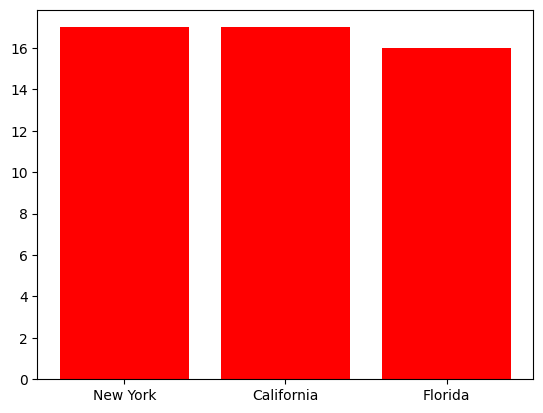

In [13]:
plt.bar(df1.index,df1.values,color='r')


In [14]:
#Feature Selection
df.corr(numeric_only=True)

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


<Axes: >

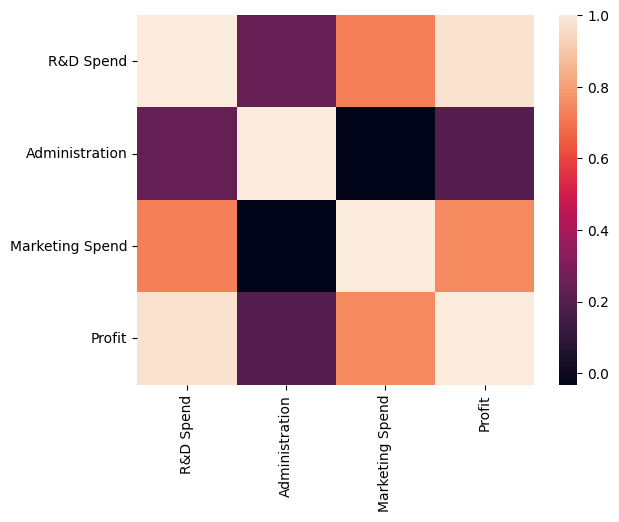

In [15]:
sns.heatmap(df.corr(numeric_only=True))

In [17]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

Text(0.5, 1.0, 'R&D vs Profit')

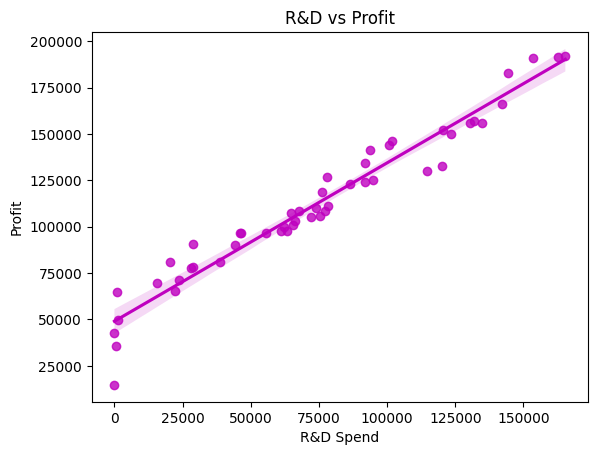

In [19]:
sns.regplot(x=df["R&D Spend"],y=y,color='m')
plt.title("R&D vs Profit")

Text(0.5, 1.0, 'add vs profit')

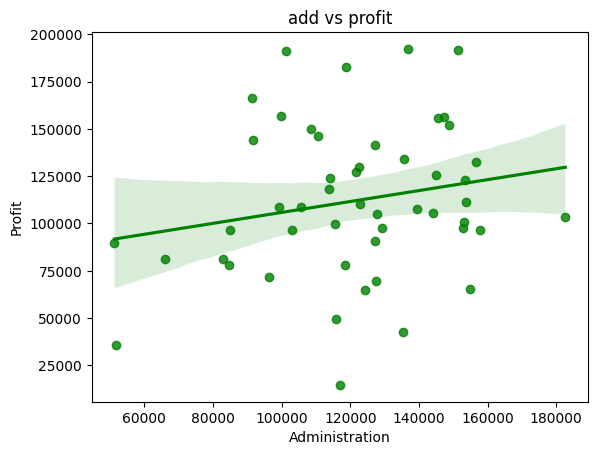

In [21]:
sns.regplot(x=df['Administration'],y=y,color='g')
plt.title("add vs profit")

Text(0.5, 1.0, 'Market vs profit')

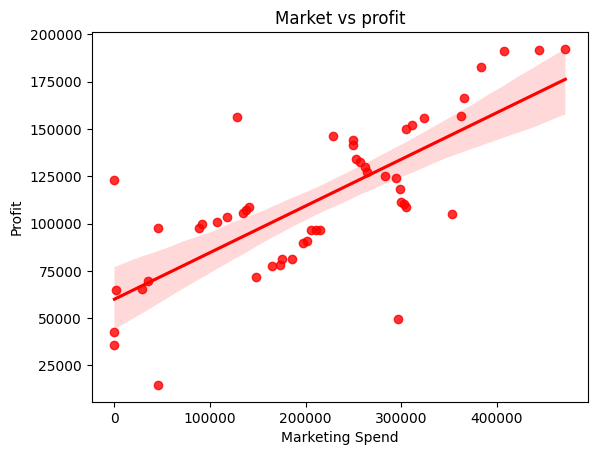

In [23]:
sns.regplot(x=df['Marketing Spend'],y=y,color='r')
plt.title('Market vs profit')

In [31]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
col=make_column_transformer((OneHotEncoder(handle_unknown='ignore'),['State']),remainder='passthrough')
x=col.fit_transform(x)
x

array([[0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.6534920e+05,
        1.3689780e+05, 4.7178410e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.6259770e+05,
        1.5137759e+05, 4.4389853e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.5344151e+05,
        1.0114555e+05, 4.0793454e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.4437241e+05,
        1.1867185e+05, 3.8319962e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.4210734e+05,
        9.1391770e+04, 3.6616842e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.3187690e+05,
        9.9814710e+04, 3.6286136e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.3461546e+05,
        1.4719887e+05, 1.2771682e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.3029813e+05,
        1.4553006e+05, 3.2387668e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.2054252e+05,
        1.4871895e+05, 3.1161329e+05],
       [1.0000000e+00, 0.0000000e+00,

In [32]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)
x_train

array([[1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 2.3640930e+04,
        9.6189630e+04, 1.4800111e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        1.1698380e+05, 4.5173060e+04],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 7.5328870e+04,
        1.4413598e+05, 1.3405007e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 7.3994560e+04,
        1.2278275e+05, 3.0331926e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 9.1992390e+04,
        1.3549507e+05, 2.5266493e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 2.7892920e+04,
        8.4710770e+04, 1.6447071e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 9.4657160e+04,
        1.4507758e+05, 2.8257431e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.0002300e+03,
        1.2415304e+05, 1.9039300e+03],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 7.7044010e+04,
        9.9281340e+04, 1.4057481e+05],
       [0.0000000e+00, 1.0000000e+00,

In [33]:
x_test

array([[0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 7.2107600e+04,
        1.2786455e+05, 3.5318381e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 4.6014020e+04,
        8.5047440e+04, 2.0551764e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 2.8754330e+04,
        1.1854605e+05, 1.7279567e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 2.0229590e+04,
        6.5947930e+04, 1.8526510e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.5344151e+05,
        1.0114555e+05, 4.0793454e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.4437241e+05,
        1.1867185e+05, 3.8319962e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 5.4205000e+02,
        5.1743150e+04, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, 6.5605480e+04,
        1.5303206e+05, 1.0713838e+05],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, 1.3154600e+03,
        1.1581621e+05, 2.9711446e+05],
       [0.0000000e+00, 0.0000000e+00,

In [34]:
y_train

42     71498.49
49     14681.40
26    105733.54
22    110352.25
13    134307.35
41     77798.83
17    125370.37
45     64926.08
24    108552.04
23    108733.99
4     166187.94
33     96778.92
14    132602.65
30     99937.59
10    146121.95
28    103282.38
44     65200.33
34     96712.80
18    124266.90
20    118474.03
25    107404.34
6     156122.51
7     155752.60
47     42559.73
1     191792.06
16    126992.93
0     192261.83
15    129917.04
5     156991.12
11    144259.40
9     149759.96
8     152211.77
12    141585.52
43     69758.98
37     89949.14
Name: Profit, dtype: float64

In [35]:
y_test

27    105008.31
35     96479.51
40     78239.91
38     81229.06
2     191050.39
3     182901.99
48     35673.41
29    101004.64
46     49490.75
31     97483.56
32     97427.84
39     81005.76
21    111313.02
36     90708.19
19    122776.86
Name: Profit, dtype: float64

In [36]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([115325.09875887,  90638.08603374,  76019.13126602,  70325.43761814,
       179659.7398274 , 172204.16410704,  48850.65280981, 101321.43054261,
        58316.95833317,  97217.64504546,  98129.2000785 ,  84156.44747449,
       117923.69116311,  75866.34008183, 113595.93339163])

In [37]:
y_test

27    105008.31
35     96479.51
40     78239.91
38     81229.06
2     191050.39
3     182901.99
48     35673.41
29    101004.64
46     49490.75
31     97483.56
32     97427.84
39     81005.76
21    111313.02
36     90708.19
19    122776.86
Name: Profit, dtype: float64

In [38]:
df1=pd.DataFrame({'actual_value':y_test,'predicted_value':y_pred,'difference':y_test-y_pred})
df1

,actual_value,predicted_value,difference
27,105008.31,115325.098759,-10316.788759
35,96479.51,90638.086034,5841.423966
40,78239.91,76019.131266,2220.778734
38,81229.06,70325.437618,10903.622382
2,191050.39,179659.739827,11390.650173
3,182901.99,172204.164107,10697.825893
48,35673.41,48850.652810,-13177.242810
29,101004.64,101321.430543,-316.790543
46,49490.75,58316.958333,-8826.208333
31,97483.56,97217.645045,265.914955


In [39]:
from sklearn.metrics import mean_absolute_percentage_error
MAPE=mean_absolute_percentage_error(y_test,y_pred)
MAPE

0.08913280081238255

In [41]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)*100
score

95.2967609542485